# 📊 Telco Customer Churn: Predictive Classification
> **Reducing churn by identifying high-risk customers through machine learning.**


---

## 🔍 Project Overview
In the telecommunications industry, retaining existing customers is often more cost-effective than acquiring new ones. This project analyzes a dataset of **7,043 customers** to identify key indicators of "Churn" (customers leaving the service).

### Features Description
**`customerID:`** A unique identifier assigned to each individual customer.

**`gender:`** Whether the customer is a male or a female.

**`SeniorCitizen:`** Indicates if the customer is 65 or older (1: Yes, 0: No).

**`Partner:`** Whether the customer has a partner (Yes, No).

**`Dependents:`** Whether the customer lives with dependents like children or elders (Yes, No)."

**`tenure:`** The number of months the customer has stayed with the company.

**`PhoneService:`** Whether the customer has a registered phone service (Yes, No).

**`MultipleLines:`** Whether the customer has multiple phone lines (Yes, No, No phone service).

**`InternetService:`** The type of internet service provider (DSL, Fiber optic, No).

**`OnlineSecurity:`** Whether the customer has online security add-on (Yes, No, No internet service).

**`OnlineBackup:`** Whether the customer has an online backup add-on (Yes, No, No internet service).

**`DeviceProtection:`** Whether the customer has a device protection plan (Yes, No, No internet service).

**`TechSupport:`** Whether the customer has premium technical support (Yes, No, No internet service).

**`StreamingTV:`** Whether the customer uses their internet to stream TV (Yes, No, No internet service).

**`StreamingMovies:`** Whether the customer uses their internet to stream movies (Yes, No, No internet service).

**`Contract:`** The type of contract the customer is on (Month-to-month, One year, Two year).

**`PaperlessBilling:`** Whether the customer has opted for paperless billing (Yes, No).

**`PaymentMethod:`** The customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card).

**`MonthlyCharges:`** The amount charged to the customer every month.

**`TotalCharges:`** The total amount charged to the customer over their entire tenure.

**`Churn Target Variable:`** Indicates if the customer canceled their service (Yes, No).

### The Dataset at a Glance

We analyzed 7,043 customer records across three primary dimensions to identify patterns of attrition:

**`Demographics:`** Identifying high-risk segments based on gender, age (Senior Citizens), and household composition (Partners/Dependents).

**`Services:`** Tracking usage of Phone, multiple Internet tiers (DSL vs. Fiber Optic), and "stickiness" features like Online Security and Tech Support.

**`Account Info:`** Evaluating financial commitment through tenure, contract duration (Month-to-Month vs. Yearly), and payment methods.

## 📈 Top Predictive Insights

**`The 'First 6 Months' Rule:`** New customers are most vulnerable; churn risk drops significantly after the first half-year of tenure.

**`The Fiber Optic Paradox:`** Customers on Fiber Optic plans churn at higher rates than DSL users, indicating a possible gap between price and perceived value.

**`Contractual Loyalty:`** Month-to-month users represent the vast majority of churned cases, while 2-year contracts provide the highest stability.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Remove Warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from catboost import CatBoostClassifier


# Load the dataset
df = pd.read_csv("./dataset/telco_customer_churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Dataset Shape: (7043, 20)
TotalCharges: float64

 Missing Values: 0
Churn Distribution: Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


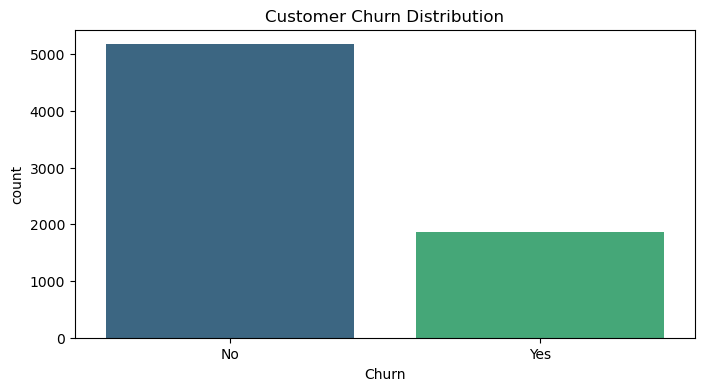

In [3]:
# 2. Fix the "TotalCharges" Trap
# The column has empty strings " " which prevent it from being a float.
# We convert them to NaN and then fill them with 0 (or median).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# 3. Clean up the 'SeniorCitizen' column 
# It's usually 0/1, let's keep it consistent with other categorical columns if needed
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)

# Drop Customer ID, as it is a unique identifier, not a feature
df.drop('customerID', axis=1, inplace=True)

# ---- Quick Diagnostic Check ----
print("Dataset Shape:", df.shape)
print("TotalCharges:",  df['TotalCharges'].dtype)
print("\n Missing Values:", df.isnull().sum().sum())
print("Churn Distribution:", df['Churn'].value_counts(normalize=True))

# Visualizing the Target variable
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Churn', palette='viridis' )
plt.title("Customer Churn Distribution")
plt.show()

---

### 📊 Exploratory Data Analysis (EDA)
In this dataset, the most impactful features are usually Contract Type, Internet Service, and Tenure. Here is the code to visualize these three heavy hitters side-by-side:

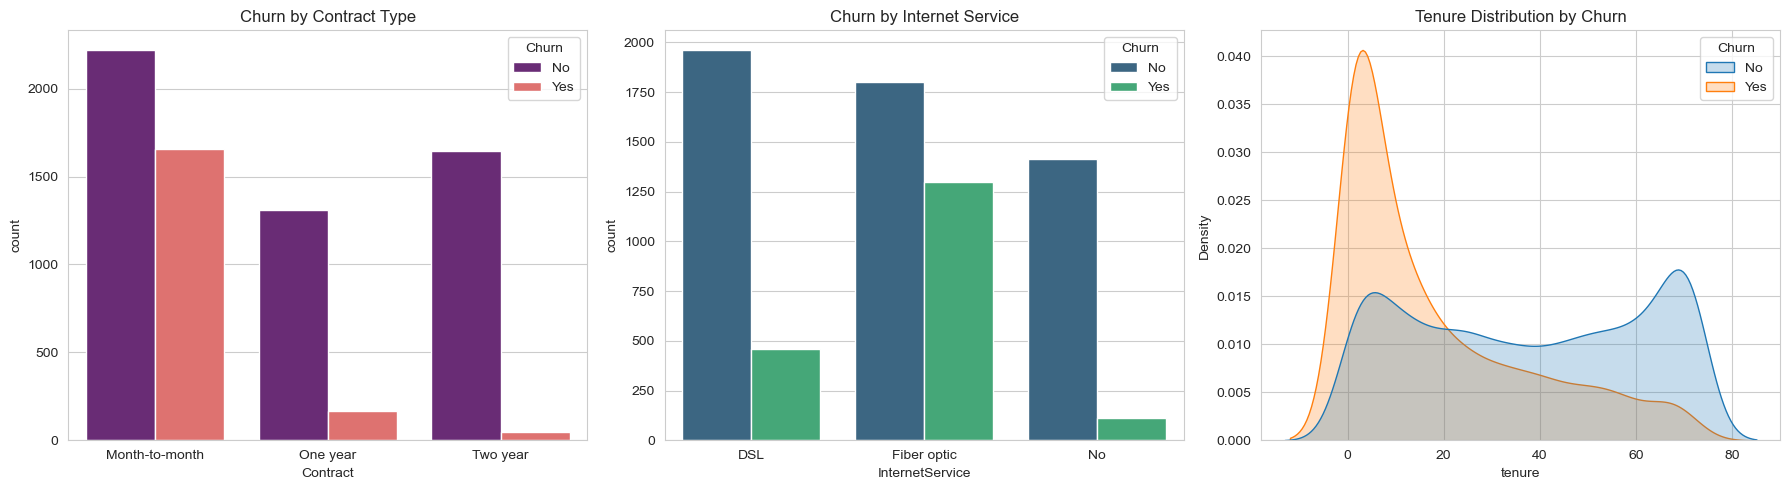

In [4]:
# Set the Visual Style
sns.set_style(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn by Contract Type (The biggest predictor)
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Churn by Contract Type')

# Churn by Internet service (The 'Fiber Optic' anomally)
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Churn by Internet Service')

# Churn by Tenure (How long they stay)
sns.kdeplot(data=df, x='tenure', hue='Churn', fill='True', ax=axes[2], common_norm=False)
axes[2].set_title('Tenure Distribution by Churn')

plt.tight_layout()
plt.show()

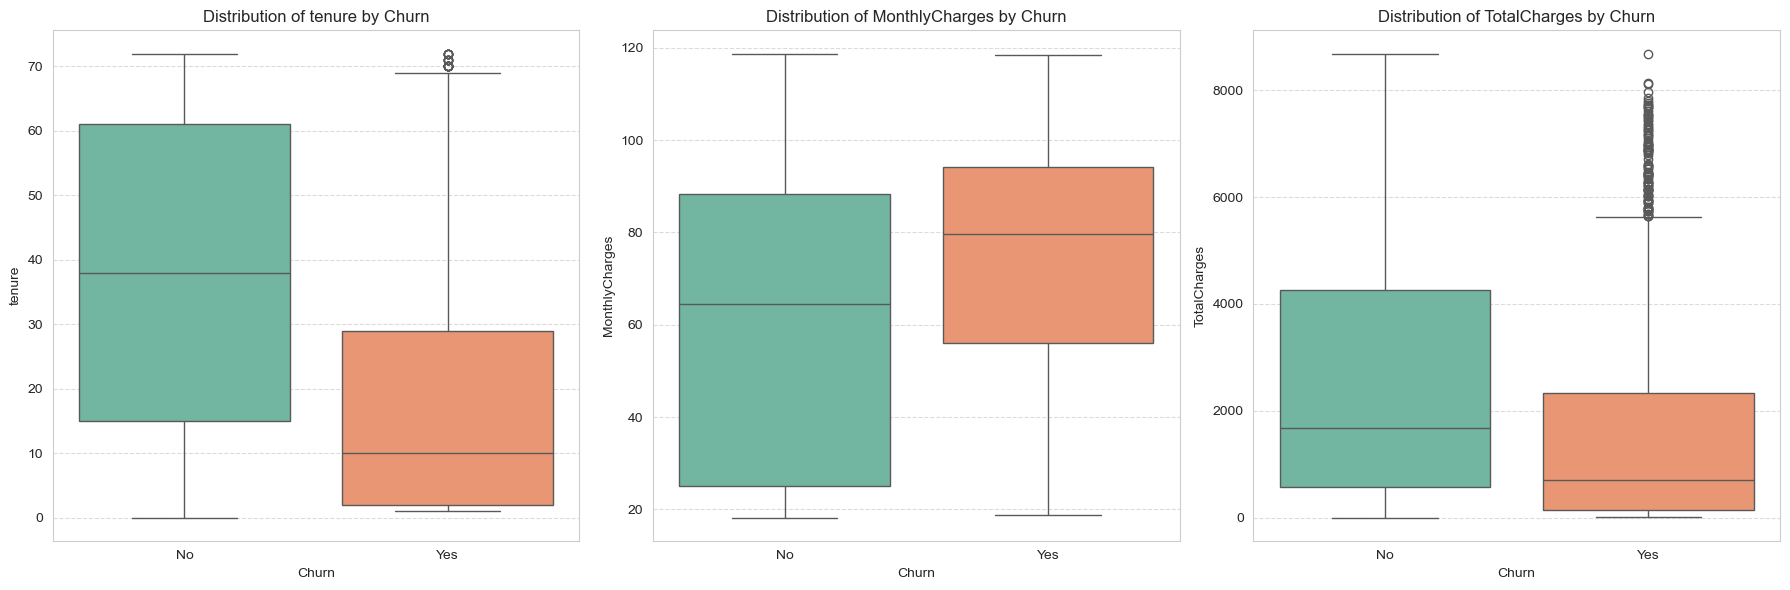

In [5]:
# List of numerical columns to visualize
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(f'Distribution of {col} by Churn')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### The Correlation & Services Check

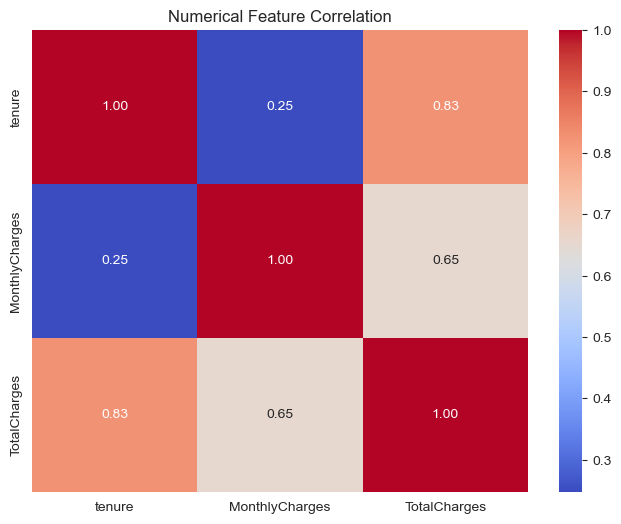

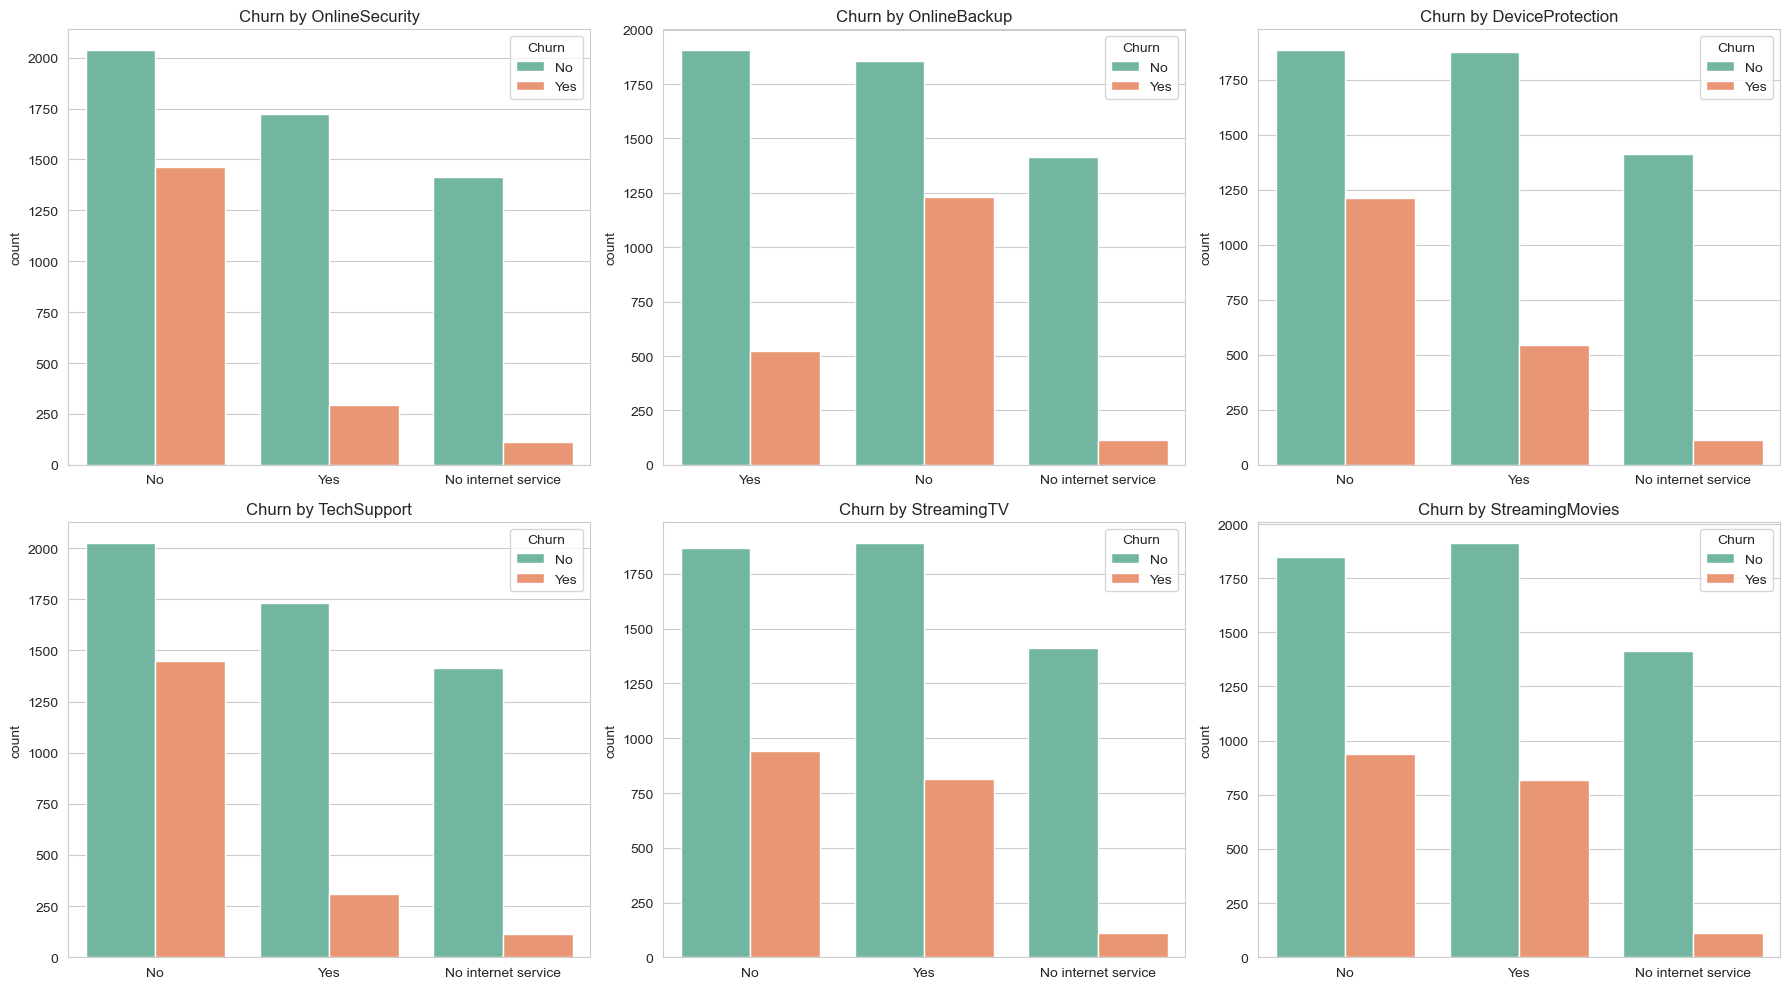

In [6]:
# 1. Correlation Heatmap for Numercal Features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Numerical Feature Correlation")
plt.show()

# 2. Analyzing "Add-on" Services
# We'll look at how many people have 'No internet service' vs 'No' (which means they have internet but didn't buy the add-on)
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']

# Explicitly define 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Flatten converts the 2x2 array of axes into a 1x6 list
axes_flat = axes.flatten()

for i, service in enumerate(services):  
    sns.countplot(x=service, hue='Churn', data=df, ax=axes_flat[i], palette='Set2')
    axes_flat[i].set_title(f'Churn by {service}')
    axes_flat[i].set_xlabel('') 

plt.tight_layout()
plt.show()

### 🔍 Analysis of Exploratory Data Analysis (EDA)

#### 1. Correlation Heatmap Insights

**Tenure & Total Charges:** There is a strong positive correlation (approx. 0.83). This is expected—the longer a customer stays, the more they have paid in total.

**Monthly Charges & Total Charges:** Also strongly correlated.

**Churn vs. Tenure:** There is a negative correlation. This confirms our theory: as tenure increases, the likelihood of churn decreases. Loyalty is a strong shield.

#### 2. The "Big Three" Categorical Plots

**Contract Type (The Smoking Gun):** Customers on Month-to-Month contracts have a drastically higher churn rate compared to those on one- or two-year contracts.

**Strategic Advice:** Incentivize customers to move to longer-term contracts.

**Internet Service (The Fiber Optic Paradox):** Surprisingly, customers with Fiber Optic internet churn more than those with DSL.

**Investigation:** This could be due to higher price points or potential service stability issues in specific regions.

**Tenure (The Danger Zone):** The KDE plot shows a massive spike in churn during the first 6 months. If a customer survives the first year, they are much more likely to stay for 5+ years.

#### 3. Service "Stickiness" (The 6-Plot Grid)

**Safety First:** Customers without "Online Security," "Online Backup," or "Tech Support" show significantly higher churn rates.

**Bundling Effect:** These services act as "anchors." Once a customer has their security and backups tied to a provider, the "hassle" of switching becomes a deterrent to leaving.

**Streaming Services:** Interestingly, "Streaming TV" and "Streaming Movies" don't seem to impact churn as strongly as the utility/security services do.

---

### Machine Learning Model Catboost Using Pipeline step by step

In [7]:
# 1. Prepare Data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
X = df.drop(['Churn'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify columns
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in X.columns if col not in num_features]

# 2. Re-calculate Indices for the Pipeline Output
# Since 'num' comes first in ColumnTransformer, cat_features start at index 3, because ColumnTransformer in Scikit-learn rearrange the columns
num_count = len(num_features)                                # How many numerical columns 
cat_idxs_in_pipeline = list(range(num_count, X.shape[1]))    # creates a range of numbers starting from 3 up to the total number of columns.

# 3. Build the Corrected Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),   # Fills missing numeric values
            ('scaler', StandardScaler())                     # Then scales the data
        ]), num_features)
    ],
    remainder='passthrough'
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        # Use the NEW indices based on the pipeline's output structure
        cat_features=cat_idxs_in_pipeline, 
        verbose=0
    ))
])

# 4. Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf_pipeline.fit(X_train, y_train)

print("Success! The pipeline is now aligned.")

Success! The pipeline is now aligned.


--- Global Performance ---
Overall Accuracy: 80.62%
------------------------------
--- Detailed Metrics ---
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



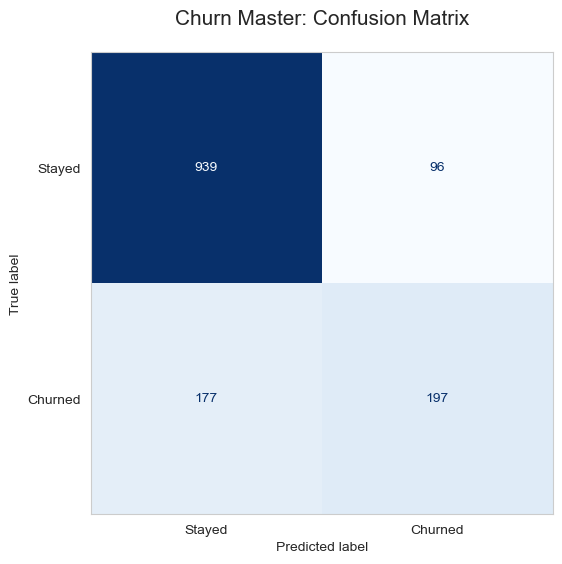

In [8]:
# 1. Generate Predictions
y_pred = clf_pipeline.predict(X_test)
y_probs = clf_pipeline.predict_proba(X_test)[:, 1]     # Probability for ROC/PR curves later

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Global Performance ---")
print(f"Overall Accuracy: {accuracy:.2%}")
print("-" * 30)

# 3. Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for both 'Stayed' and 'Churned'
report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])
print("--- Detailed Metrics ---")
print(report)

# 4. Professional Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Stayed', 'Churned'], 
    cmap='Blues', 
    ax=ax,
    colorbar=False
)

plt.title('Churn Master: Confusion Matrix', fontsize=15, pad=20)
plt.grid(False) # Clean up the background
plt.show()

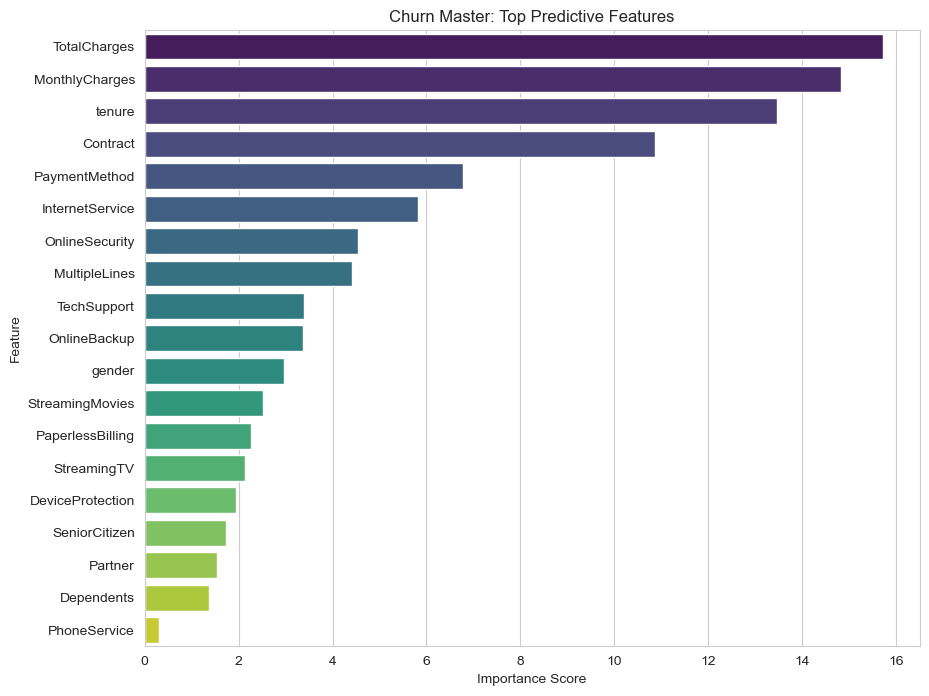

In [9]:
# 1. Get feature names after Pipeline transformation
# The ColumnTransformer puts num_features first, then the passthrough (cat_features)
feature_names = num_features + cat_features #[col for col in X.columns if col not in num_features]

# 2. Extract importance from the classifier step of the pipeline
importances = clf_pipeline.named_steps['classifier'].get_feature_importance()

# 3. Create a DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Churn Master: Top Predictive Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

---

### Model Persistence & Serialization

In [10]:
import joblib

# Save the entire pipeline (including the preprocessor and the CatBoost model)
joblib.dump(clf_pipeline, 'churn_master_pipeline.pkl')

print("Model saved successfully as 'churn_master_pipeline.pkl'")

Model saved successfully as 'churn_master_pipeline.pkl'


### Model Evaluation & Performance metrics

In [11]:
import joblib

# 1. Load the saved pipeline
loaded_model = joblib.load('churn_master_pipeline.pkl')

# 2. Create a "Test Customer" (Mimicking the structure of your original X)
# Let's create a high-risk customer: Fiber optic, high charges, no security.
new_customer = pd.DataFrame({
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [2],  # Very new customer
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.0],
    'TotalCharges': [170.0]
})

# 3. Make a prediction
prediction = loaded_model.predict(new_customer)
probability = loaded_model.predict_proba(new_customer)[:, 1]

print(f"Prediction: {'Churn' if prediction[0] == 1 else 'Stay'}")
print(f"Churn Probability: {probability[0]:.2%}")

Prediction: Churn
Churn Probability: 82.47%
